In [1]:
import pickle as pkl
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt
import os
%load_ext autoreload
%autoreload 2

from dotenv import load_dotenv
load_dotenv()
import ipywidgets

In [2]:
os.environ["SCRATCH"] = "/farmshare/user_data/vivek772/stats-305c-data"

In [3]:
with open(f"{os.environ['SCRATCH']}/mc_pacman.pkl", "rb") as f:
    data = pkl.load(f)

In [4]:
# Top-level structure overview
if isinstance(data, dict):
    print(f"Top-level object: dict with {len(data)} keys")
    print("Keys:", list(data.keys()))
else:
    print(f"Top-level object type: {type(data).__name__}")


def _safe_shape(x):
    try:
        if hasattr(x, "shape"):
            return tuple(x.shape)
    except Exception:
        pass

    if isinstance(x, (list, tuple)):
        try:
            if len(x) > 0 and hasattr(x[0], "shape"):
                return (len(x), tuple(x[0].shape))
            return (len(x),)
        except Exception:
            return None

    return None


def _safe_len(x):
    try:
        return len(x)
    except Exception:
        return None


def _safe_nbytes(x):
    # Prefer native memory estimates when available
    if hasattr(x, "nbytes"):
        try:
            return int(x.nbytes)
        except Exception:
            pass

    # pandas objects
    if hasattr(x, "memory_usage"):
        try:
            mem = x.memory_usage(deep=True)
            if hasattr(mem, "sum"):
                return int(mem.sum())
            return int(mem)
        except Exception:
            pass

    return None


def _head_repr(x, n=5):
    # pandas DataFrame/Series
    if hasattr(x, "head"):
        try:
            return x.head(n)
        except Exception:
            pass

    # list/tuple
    if isinstance(x, (list, tuple)):
        return x[:n]

    # dict
    if isinstance(x, dict):
        keys = list(x.keys())[:n]
        return {k: x[k] for k in keys}

    # numpy array-like preview
    if isinstance(x, np.ndarray):
        return x[:n]

    return repr(x)


def summarize_item(name, obj, n_head=5):
    print("\n" + "=" * 80)
    print(f"Name: {name}")
    print(f"Type: {type(obj).__name__}")

    shape = _safe_shape(obj)
    length = _safe_len(obj)
    nbytes = _safe_nbytes(obj)

    print(f"Shape: {shape}")
    print(f"Len/Count: {length}")
    print(f"Approx. size (bytes): {nbytes}")

    if isinstance(obj, dict):
        print(f"Nested keys ({len(obj)}): {list(obj.keys())[:20]}")

    print(f"Head (first {n_head}):")
    print(_head_repr(obj, n=n_head))


if isinstance(data, dict):
    for key, value in data.items():
        summarize_item(key, value)
else:
    summarize_item("data", data)



Top-level object: dict with 3 keys
Keys: ['condition', 'force', 'spikes']

Name: condition
Type: ndarray
Shape: (362,)
Len/Count: 362
Approx. size (bytes): 2896
Head (first 5):
[1 1 1 1 1]

Name: force
Type: list
Shape: (362, (1, 6001))
Len/Count: 362
Approx. size (bytes): None
Head (first 5):
[array([[ 0.48096287,  0.48211542,  0.48328225, ..., 16.46273806,
        16.45690032, 16.45105931]], shape=(1, 6001)), array([[-0.14623348, -0.14721349, -0.14811278, ..., 15.38443233,
        15.38507463, 15.38569108]], shape=(1, 6001)), array([[-0.4090799 , -0.40837236, -0.40762928, ..., 16.88461884,
        16.88489787, 16.88516871]], shape=(1, 6001)), array([[-0.56630798, -0.56438659, -0.56256519, ..., 16.3202097 ,
        16.31994742, 16.31965903]], shape=(1, 6001)), array([[ 0.20535427,  0.20523017,  0.20511521, ..., 16.93372462,
        16.93364399, 16.93351709]], shape=(1, 6001))]

Name: spikes
Type: list
Shape: (362, (128, 6001))
Len/Count: 362
Approx. size (bytes): None
Head (first 5):


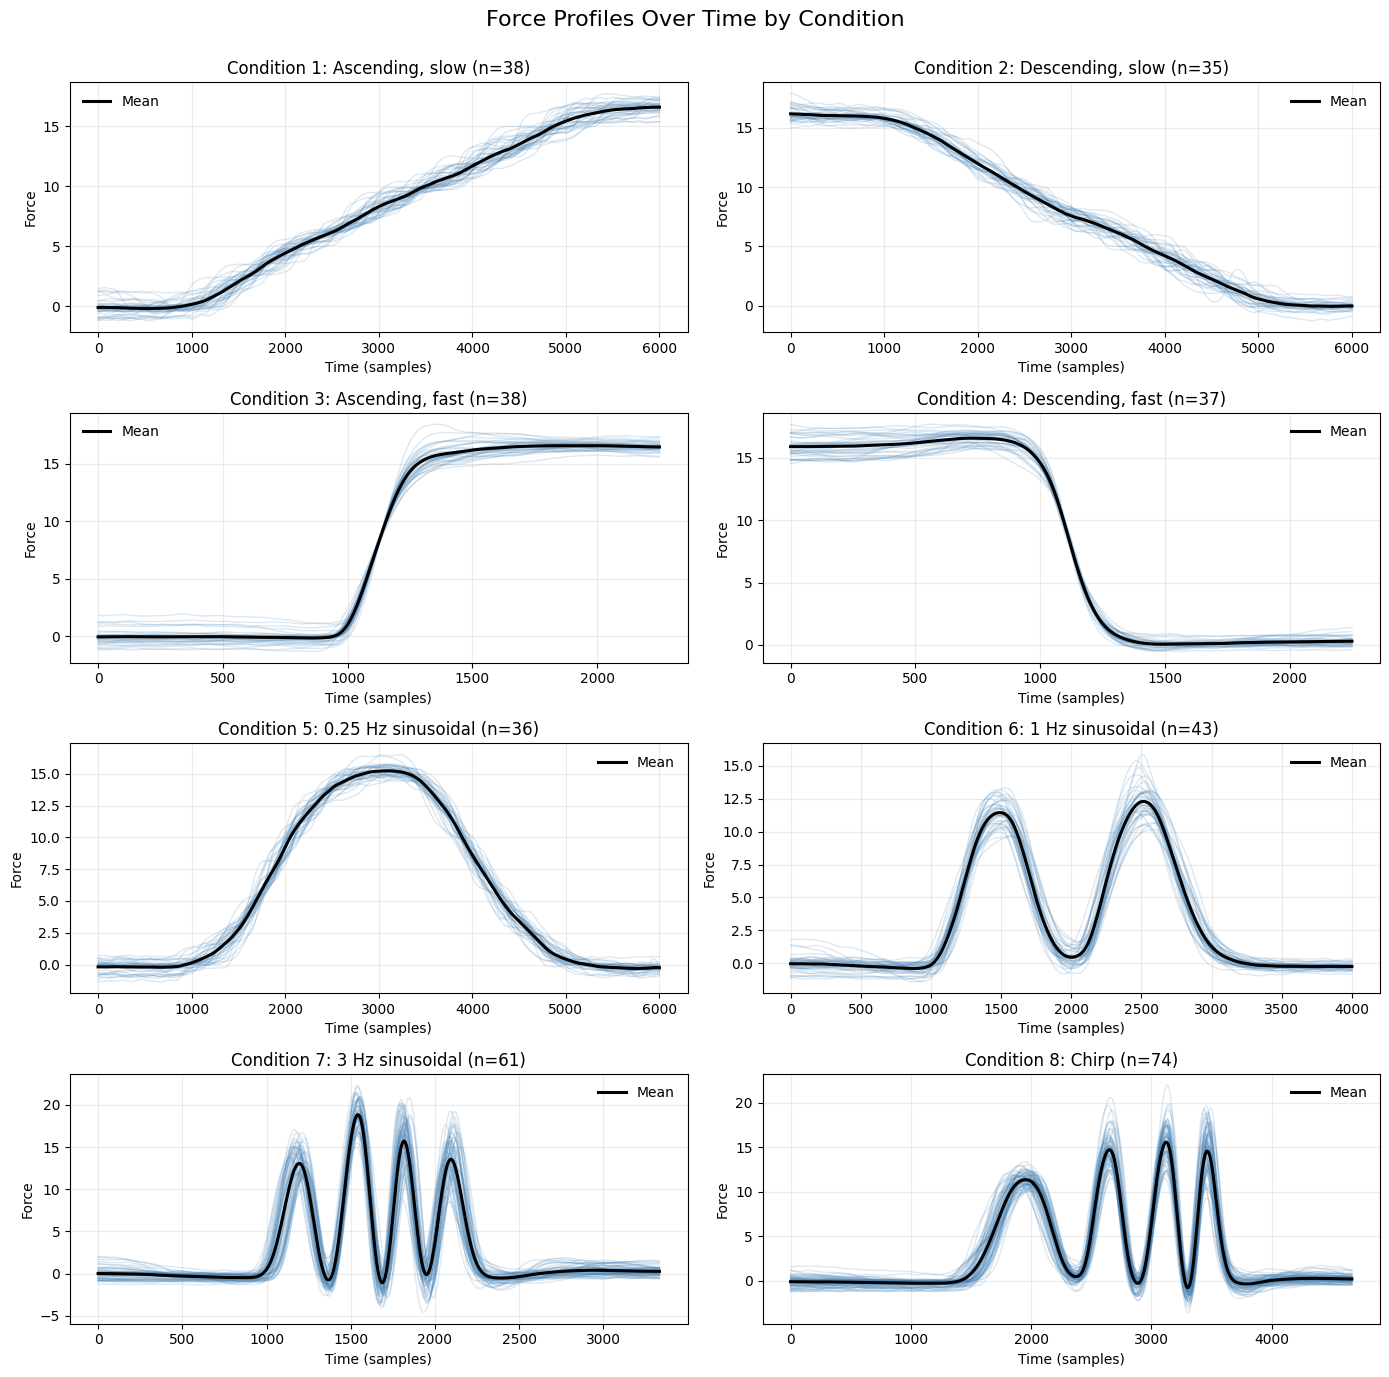

In [ ]:
force_profiles = {
1: "Ascending, slow",
2: "Descending, slow",
3: "Ascending, fast",
4: "Descending, fast",
5: "0.25 Hz sinusoidal",
6: "1 Hz sinusoidal",
7: "3 Hz sinusoidal",
8: "Chirp"
}

import numpy as np
import matplotlib.pyplot as plt

# ---- Build one figure with 8 subplots: force-over-time for conditions 1..8 ----
if not isinstance(data, dict):
    raise TypeError(f"Expected `data` to be dict, got {type(data).__name__}")


def _find_key(d, candidates):
    for k in d.keys():
        lk = k.lower()
        if any(c in lk for c in candidates):
            return k
    return None


def _to_1d_array(x):
    a = np.asarray(x)
    return a.ravel()


force_key = _find_key(data, ["force"])
cond_key = _find_key(data, ["condition", "cond", "trialtype", "trial_type", "label"])
time_key = _find_key(data, ["time", "t", "timestamps"])

if force_key is None:
    raise KeyError(f"Could not find a force key in data. Available keys: {list(data.keys())}")
if cond_key is None:
    raise KeyError(
        "Could not find a condition key in data. "
        f"Available keys: {list(data.keys())}"
    )

forces = data[force_key]
conds = _to_1d_array(data[cond_key])

if len(forces) != len(conds):
    raise ValueError(
        f"Mismatch: len(data['{force_key}'])={len(forces)} vs len(data['{cond_key}'])={len(conds)}"
    )

# Optional global time vector
shared_t = None
if time_key is not None:
    t_candidate = np.asarray(data[time_key])
    if t_candidate.ndim == 1:
        shared_t = t_candidate

fig, axes = plt.subplots(4, 2, figsize=(8, 8), sharex=False, sharey=False)
axes = axes.ravel()

for cond in range(1, 9):
    ax = axes[cond - 1]
    idx = np.where(conds == cond)[0]

    if len(idx) == 0:
        label = force_profiles.get(cond, "Unknown")
        ax.set_title(f"Condition {cond}: {label} (n=0)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Force")
        ax.grid(alpha=0.25)
        continue

    trial_curves = []
    min_len = None
    xlab = "Time (samples)"

    for i in idx:
        y = _to_1d_array(forces[i])
        if y.size == 0:
            continue

        if shared_t is not None and len(shared_t) == len(y):
            x = shared_t
            xlab = "Time"
        else:
            x = np.arange(len(y))

        ax.plot(x, y, color="steelblue", alpha=0.18, linewidth=1)
        trial_curves.append(y)
        min_len = len(y) if min_len is None else min(min_len, len(y))

    if trial_curves and min_len and min_len > 1:
        aligned = np.vstack([y[:min_len] for y in trial_curves])
        mean_curve = aligned.mean(axis=0)

        if shared_t is not None and len(shared_t) >= min_len:
            x_mean = shared_t[:min_len]
            xlab = "Time"
        else:
            x_mean = np.arange(min_len)

        ax.plot(x_mean, mean_curve, color="black", linewidth=2.2, label="Mean")
        ax.legend(frameon=False)

    label = force_profiles.get(cond, "Unknown")
    ax.set_title(f"Condition {cond}: {label} (n={len(idx)})")
    ax.set_xlabel(xlab)
    ax.set_ylabel("Force")
    ax.grid(alpha=0.25)

fig.suptitle("Force Profiles Over Time by Condition", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



interactive(children=(IntSlider(value=1, description='Condition', max=8, min=1), IntSlider(value=0, descriptio…

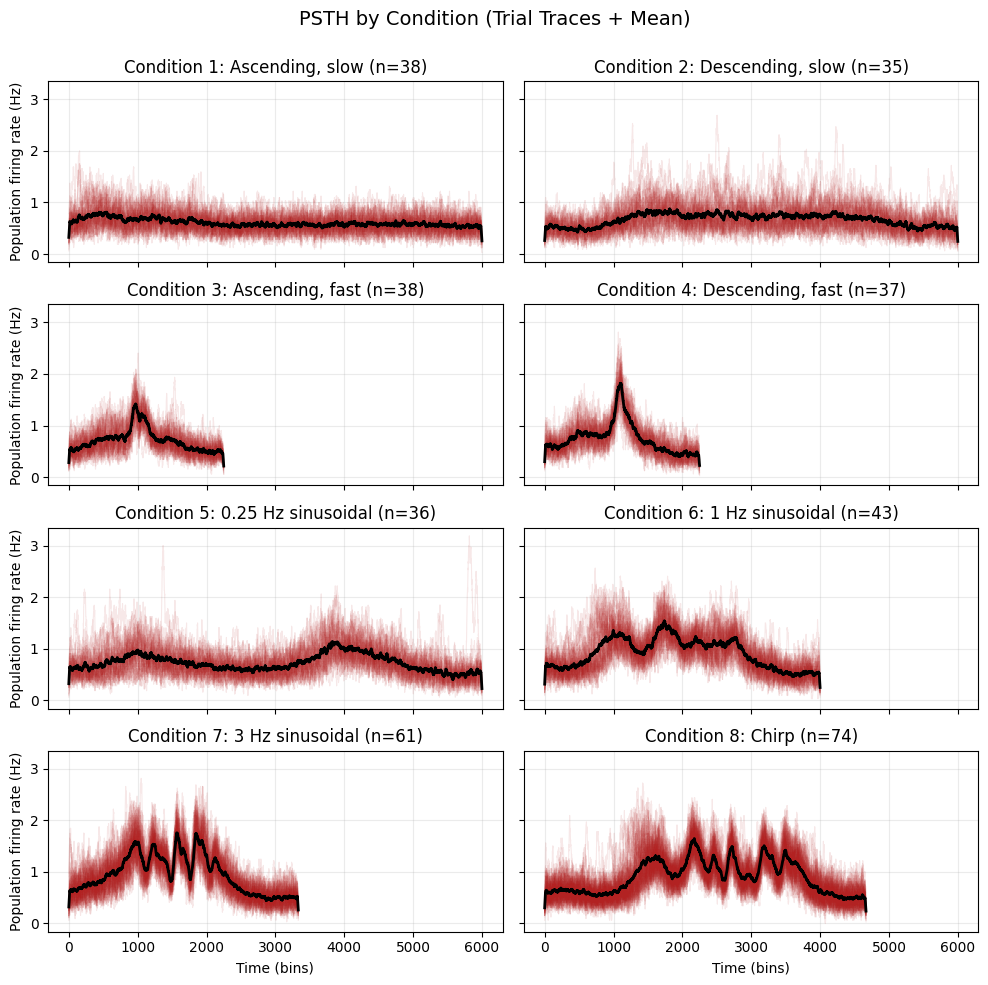

In [11]:
# ---- Spiking plots by condition: (1) interactive raster, (2) PSTH ----
if not isinstance(data, dict):
    raise TypeError(f"Expected `data` to be dict, got {type(data).__name__}")


def _find_key(d, candidates):
    for k in d.keys():
        lk = k.lower()
        if any(c in lk for c in candidates):
            return k
    return None


def _as_neuron_time(sp):
    """Return spikes array as shape (neurons, time)."""
    arr = np.asarray(sp)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D spikes array, got shape {arr.shape}")

    # Heuristic: neurons are usually fewer than time bins.
    if arr.shape[0] <= arr.shape[1]:
        return arr
    return arr.T


def _moving_average(x, win=25):
    if win <= 1:
        return x
    k = np.ones(win, dtype=float) / win
    return np.convolve(x, k, mode="same")


spike_key = _find_key(data, ["spike", "spikes"])
cond_key = _find_key(data, ["condition", "cond", "trialtype", "trial_type", "label"])

if spike_key is None:
    raise KeyError(f"Could not find a spikes key in data. Available keys: {list(data.keys())}")
if cond_key is None:
    raise KeyError(f"Could not find a condition key in data. Available keys: {list(data.keys())}")

spikes = data[spike_key]
conds = np.asarray(data[cond_key]).ravel()

if len(spikes) != len(conds):
    raise ValueError(
        f"Mismatch: len(data['{spike_key}'])={len(spikes)} vs len(data['{cond_key}'])={len(conds)}"
    )

cond_to_trials = {c: np.where(conds == c)[0] for c in range(1, 9)}
max_trials_in_any_cond = max(len(v) for v in cond_to_trials.values())

from ipywidgets import interact, IntSlider


def plot_single_condition_raster(condition=1, trial_rank=0, max_points=120000):
    """
    condition: condition id (1..8).
    trial_rank: kth trial within selected condition (0-indexed).
    max_points: cap on plotted spike events to keep rendering responsive.
    """
    if condition not in cond_to_trials:
        raise ValueError(f"Condition {condition} not found. Valid: {list(cond_to_trials.keys())}")

    trial_ids = cond_to_trials[condition]
    label = force_profiles.get(condition, "Unknown")

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    if len(trial_ids) == 0:
        ax.set_title(f"Condition {condition}: {label} (n=0)")
        ax.set_xlabel("Time (bins)")
        ax.set_ylabel("Neuron index")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
        return

    selected_id = trial_ids[trial_rank % len(trial_ids)]
    trial_sp = _as_neuron_time(spikes[selected_id])
    neuron_idx, time_idx = np.where(trial_sp > 0)

    # Keep plotting responsive if a trial has many spikes.
    if len(time_idx) > max_points:
        keep = np.linspace(0, len(time_idx) - 1, max_points, dtype=int)
        neuron_idx = neuron_idx[keep]
        time_idx = time_idx[keep]

    ax.scatter(time_idx, neuron_idx, s=4, c="black", alpha=0.75, linewidths=0)
    ax.set_title(
        f"Raster | Cond {condition}: {label} | trial {trial_rank % len(trial_ids)} "
        f"(global id={selected_id}, n={len(trial_ids)})"
    )
    ax.set_xlabel("Time (bins)")
    ax.set_ylabel("Neuron index")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


interact(
    plot_single_condition_raster,
    condition=IntSlider(value=1, min=1, max=8, step=1, description="Condition"),
    trial_rank=IntSlider(value=0, min=0, max=max(0, max_trials_in_any_cond - 1), step=1, description="Trial rank"),
)


# ---------------------------------------------
# 2) PSTH-style plot (8 subplots, one per cond)
# ---------------------------------------------
# If each time bin is 1 ms, this converts spike probability/bin to Hz.
bin_size_ms = 10.0
hz_scale = 1000.0 / bin_size_ms

fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.ravel()

for cond in range(1, 9):
    ax = axes[cond - 1]
    trial_ids = cond_to_trials[cond]
    label = force_profiles.get(cond, "Unknown")

    if len(trial_ids) == 0:
        ax.set_title(f"Condition {cond}: {label} (n=0)")
        ax.grid(alpha=0.25)
        continue

    traces = []
    min_len = None

    for trial_id in trial_ids:
        trial_sp = _as_neuron_time(spikes[trial_id])
        pop_rate = trial_sp.mean(axis=0).astype(float) * hz_scale
        traces.append(pop_rate)
        min_len = len(pop_rate) if min_len is None else min(min_len, len(pop_rate))

    if min_len is None or min_len < 2:
        ax.set_title(f"Condition {cond}: {label} (n={len(trial_ids)})")
        ax.grid(alpha=0.25)
        continue

    aligned = np.vstack([t[:min_len] for t in traces])
    smoothed = np.vstack([_moving_average(t, win=25) for t in aligned])

    x = np.arange(min_len)

    for t in smoothed:
        ax.plot(x, t, color="firebrick", alpha=0.10, linewidth=0.8)

    mean_t = smoothed.mean(axis=0)
    ax.plot(x, mean_t, color="black", linewidth=2.0)

    ax.set_title(f"Condition {cond}: {label} (n={len(trial_ids)})")
    ax.grid(alpha=0.25)

for ax in axes[-2:]:
    ax.set_xlabel("Time (bins)")
for i in [0, 2, 4, 6]:
    axes[i].set_ylabel("Population firing rate (Hz)")

fig.suptitle("PSTH by Condition (Trial Traces + Mean)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()




Trials: 362, Units: 128, Bins: 112, Valid conditions: [1, 2, 3, 4, 5, 6, 7, 8]
Explained variance ratio (PC1-5): [0.3445 0.128  0.0737 0.061  0.0574]


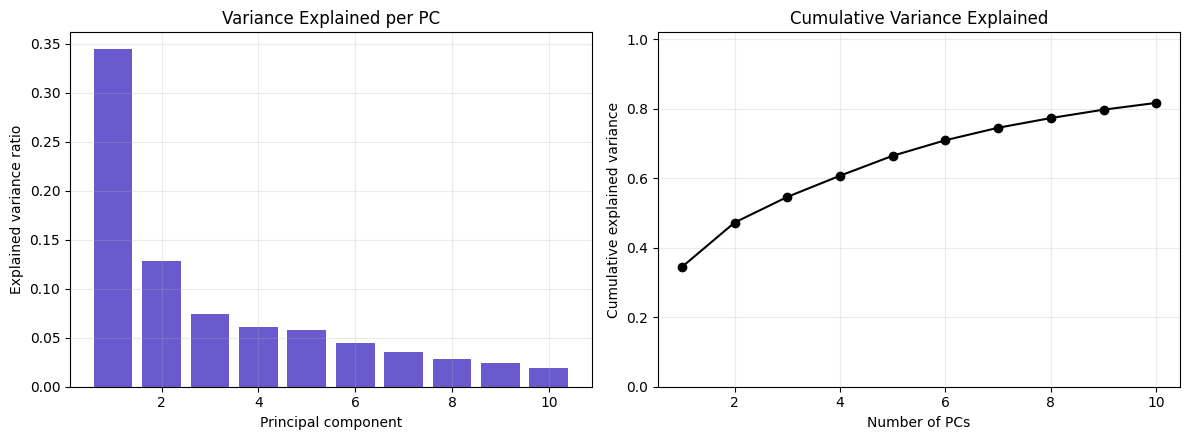

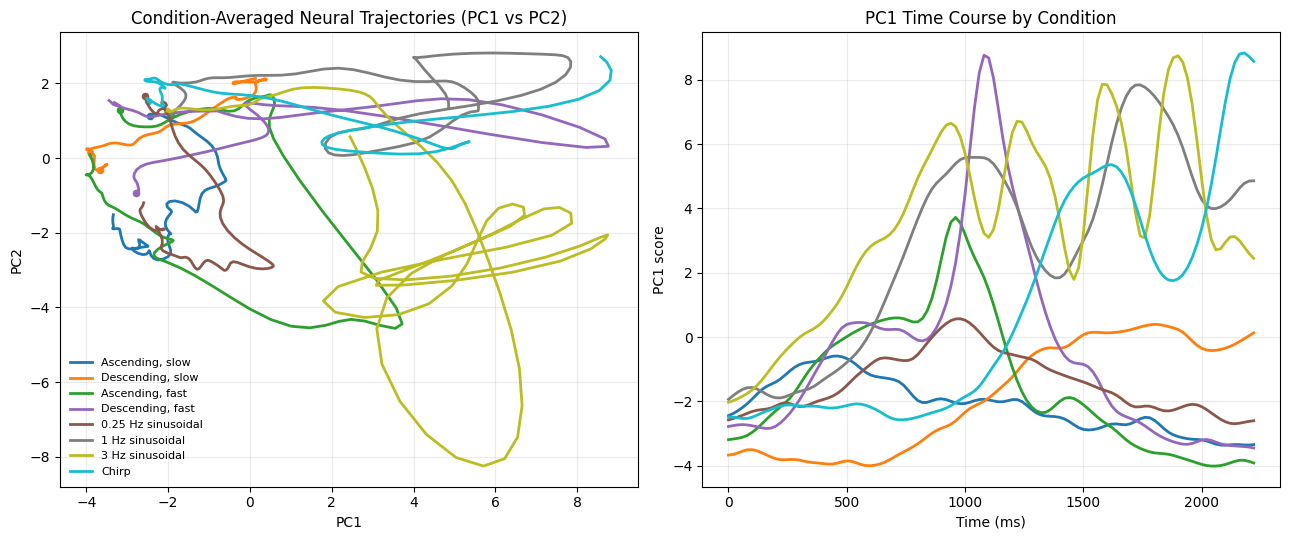

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PCA on sorted single-unit spiking (motor-neuroscience style) ----
# Pipeline:
# 1) convert spikes to firing rates in bins
# 2) smooth rates over time
# 3) trial-average by condition (denoised trajectories)
# 4) soft-normalize each unit and mean-center
# 5) PCA via SVD on condition x time observations

if not isinstance(data, dict):
    raise TypeError(f"Expected `data` to be dict, got {type(data).__name__}")


def _find_key(d, candidates):
    for k in d.keys():
        lk = k.lower()
        if any(c in lk for c in candidates):
            return k
    return None


def _as_neuron_time(sp):
    arr = np.asarray(sp)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D spikes array, got shape {arr.shape}")
    return arr if arr.shape[0] <= arr.shape[1] else arr.T


spike_key = _find_key(data, ["spike", "spikes"])
cond_key = _find_key(data, ["condition", "cond", "trialtype", "trial_type", "label"])

if spike_key is None:
    raise KeyError(f"Could not find spikes key. Available keys: {list(data.keys())}")
if cond_key is None:
    raise KeyError(f"Could not find condition key. Available keys: {list(data.keys())}")

spikes = data[spike_key]
conds = np.asarray(data[cond_key]).ravel()
cond_ids = np.arange(1, 9)

if len(spikes) != len(conds):
    raise ValueError(
        f"Mismatch: len(data['{spike_key}'])={len(spikes)} vs len(data['{cond_key}'])={len(conds)}"
    )

# Parameters (adjust as needed)
bin_ms = 20.0
smooth_ms = 40.0
softnorm_const = 5.0

# Match all trials to common time length, then bin
T_min = min(_as_neuron_time(s).shape[1] for s in spikes)
N_units = _as_neuron_time(spikes[0]).shape[0]
n_bins = int(T_min // bin_ms)

if n_bins < 2:
    raise ValueError("Not enough time bins after binning; reduce bin_ms.")

trial_rates = []
for s in spikes:
    st = _as_neuron_time(s)[:, : int(n_bins * bin_ms)]  # (units, time)
    binned = st.reshape(N_units, n_bins, int(bin_ms)).sum(axis=2)
    rate_hz = binned * (1000.0 / bin_ms)
    trial_rates.append(rate_hz)

trial_rates = np.stack(trial_rates, axis=0)  # (trials, units, bins)

# Temporal smoothing
sigma_bins = smooth_ms / bin_ms
trial_rates = gaussian_filter1d(trial_rates, sigma=sigma_bins, axis=2, mode="nearest")

# Condition-averaged neural trajectories (denoised)
cond_avg = []  # list of (units, bins)
for c in cond_ids:
    idx = np.where(conds == c)[0]
    if len(idx) == 0:
        cond_avg.append(np.full((N_units, n_bins), np.nan))
    else:
        cond_avg.append(trial_rates[idx].mean(axis=0))
cond_avg = np.stack(cond_avg, axis=0)  # (conditions, units, bins)

valid_cond_mask = ~np.isnan(cond_avg).any(axis=(1, 2))
if valid_cond_mask.sum() < 2:
    raise ValueError("Not enough valid conditions to run PCA.")

cond_avg_valid = cond_avg[valid_cond_mask]
cond_ids_valid = cond_ids[valid_cond_mask]

# Build PCA data matrix: observations=(condition,time), features=units
X = cond_avg_valid.transpose(0, 2, 1).reshape(len(cond_ids_valid) * n_bins, N_units)

# Soft-normalize each unit then mean-center (common for neural population analyses)
unit_std = X.std(axis=0, ddof=1)
X_norm = X / (unit_std + softnorm_const)
X_centered = X_norm - X_norm.mean(axis=0, keepdims=True)

# PCA via SVD (equivalent to standard PCA)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
pcs = Vt.T                      # columns are PC loading vectors (units x PCs)
scores = U * S                  # projected observations (obs x PCs)
expl_var = (S ** 2) / (X_centered.shape[0] - 1)
expl_var_ratio = expl_var / expl_var.sum()

# Reshape scores back to condition trajectories in PC space
traj = scores.reshape(len(cond_ids_valid), n_bins, -1)  # (conditions, time, PCs)
time_ms = np.arange(n_bins) * bin_ms

print(f"Trials: {len(spikes)}, Units: {N_units}, Bins: {n_bins}, Valid conditions: {cond_ids_valid.tolist()}")
print("Explained variance ratio (PC1-5):", np.round(expl_var_ratio[:5], 4))

# -------- Plot 1: explained variance --------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

n_show = min(10, len(expl_var_ratio))
axes[0].bar(np.arange(1, n_show + 1), expl_var_ratio[:n_show], color="slateblue")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Variance Explained per PC")
axes[0].grid(alpha=0.25)

axes[1].plot(np.arange(1, n_show + 1), np.cumsum(expl_var_ratio[:n_show]), marker="o", color="black")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

# -------- Plot 2: condition trajectories in PC space --------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(cond_ids_valid)))

for i, c in enumerate(cond_ids_valid):
    label = force_profiles.get(int(c), f"Condition {int(c)}") if "force_profiles" in globals() else f"Condition {int(c)}"
    axes[0].plot(traj[i, :, 0], traj[i, :, 1], color=colors[i], lw=2, label=label)
    axes[0].scatter(traj[i, 0, 0], traj[i, 0, 1], color=colors[i], s=20)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Condition-Averaged Neural Trajectories (PC1 vs PC2)")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)

for i, c in enumerate(cond_ids_valid):
    label = force_profiles.get(int(c), f"Condition {int(c)}") if "force_profiles" in globals() else f"Condition {int(c)}"
    axes[1].plot(time_ms, traj[i, :, 0], color=colors[i], lw=2, label=label)

axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("PC1 score")
axes[1].set_title("PC1 Time Course by Condition")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()



Single-trial PCA: trials=362, units=128, bins=112
Explained variance ratio (PC1-5): [0.144  0.0542 0.0404 0.0325 0.0306]


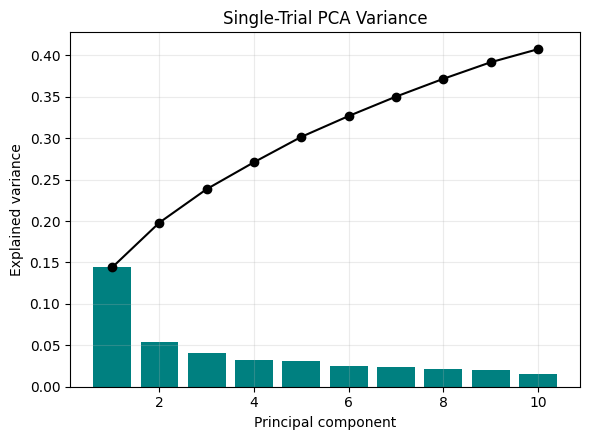

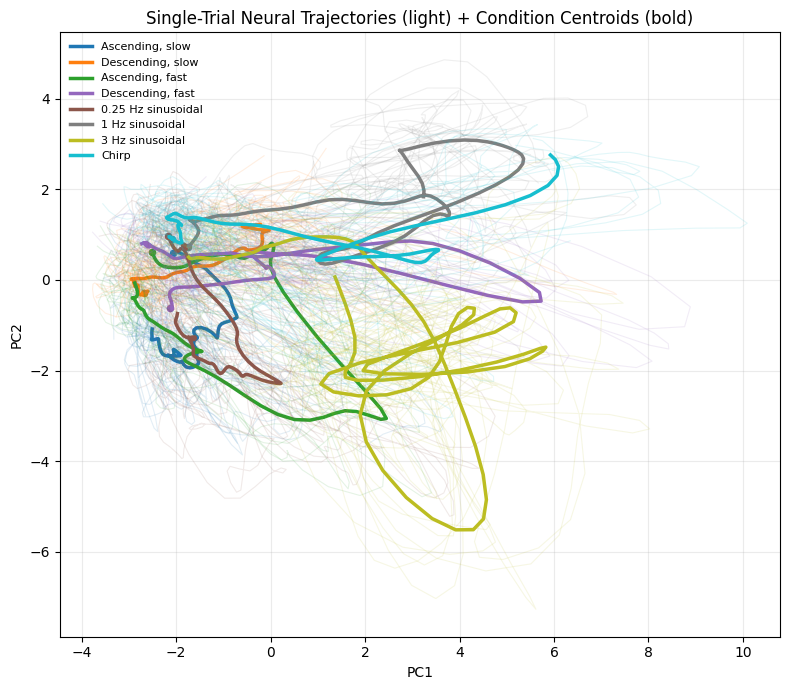

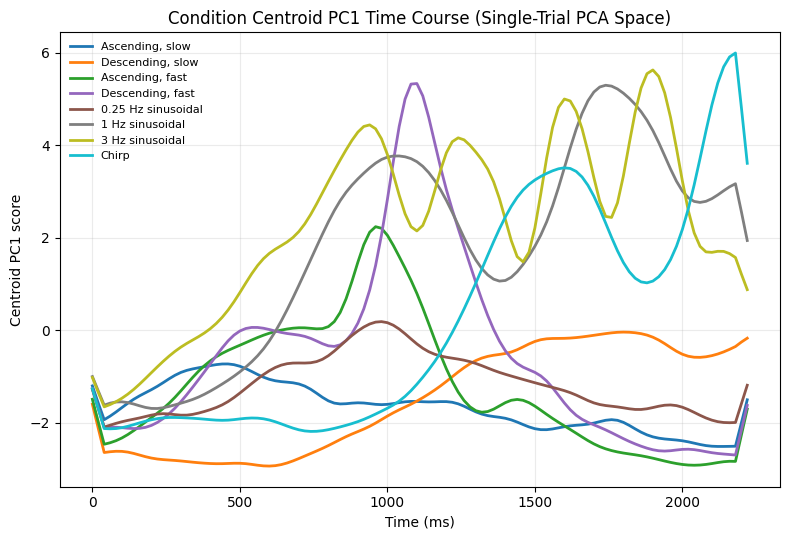

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PCA on single-trial neural activity + condition centroids ----
# This complements the condition-averaged PCA by preserving trial-level variability.

if not isinstance(data, dict):
    raise TypeError(f"Expected `data` to be dict, got {type(data).__name__}")


def _find_key(d, candidates):
    for k in d.keys():
        lk = k.lower()
        if any(c in lk for c in candidates):
            return k
    return None


def _as_neuron_time(sp):
    arr = np.asarray(sp)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D spikes array, got shape {arr.shape}")
    return arr if arr.shape[0] <= arr.shape[1] else arr.T


def _moving_average(x, win=5):
    if win <= 1:
        return x
    k = np.ones(win, dtype=float) / win
    return np.convolve(x, k, mode="same")


spike_key = _find_key(data, ["spike", "spikes"])
cond_key = _find_key(data, ["condition", "cond", "trialtype", "trial_type", "label"])

if spike_key is None:
    raise KeyError(f"Could not find spikes key. Available keys: {list(data.keys())}")
if cond_key is None:
    raise KeyError(f"Could not find condition key. Available keys: {list(data.keys())}")

spikes = data[spike_key]
conds = np.asarray(data[cond_key]).ravel()
cond_ids = np.arange(1, 9)

if len(spikes) != len(conds):
    raise ValueError(
        f"Mismatch: len(data['{spike_key}'])={len(spikes)} vs len(data['{cond_key}'])={len(conds)}"
    )

# Parameters
bin_ms = 20.0
smooth_ms = 40.0
softnorm_const = 5.0

# Build single-trial firing rates
T_min = min(_as_neuron_time(s).shape[1] for s in spikes)
N_units = _as_neuron_time(spikes[0]).shape[0]
n_bins = int(T_min // bin_ms)

if n_bins < 2:
    raise ValueError("Not enough time bins after binning; reduce bin_ms.")

trial_rates = []
for s in spikes:
    st = _as_neuron_time(s)[:, : int(n_bins * bin_ms)]
    binned = st.reshape(N_units, n_bins, int(bin_ms)).sum(axis=2)
    rate_hz = binned * (1000.0 / bin_ms)
    trial_rates.append(rate_hz)

trial_rates = np.stack(trial_rates, axis=0)  # (trials, units, bins)
trial_rates = gaussian_filter1d(trial_rates, sigma=(smooth_ms / bin_ms), axis=2, mode="nearest")

# PCA matrix: observations=(trial,time), features=units
X = trial_rates.transpose(0, 2, 1).reshape(len(spikes) * n_bins, N_units)
unit_std = X.std(axis=0, ddof=1)
X_norm = X / (unit_std + softnorm_const)
X_centered = X_norm - X_norm.mean(axis=0, keepdims=True)

# PCA via SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
scores = U * S
expl_var = (S ** 2) / (X_centered.shape[0] - 1)
expl_var_ratio = expl_var / expl_var.sum()

# Reshape back to trial trajectories in PC space
trial_traj = scores.reshape(len(spikes), n_bins, -1)  # (trials, time, PCs)
time_ms = np.arange(n_bins) * bin_ms

# Condition mean trajectories (centroids) in PC space
cond_centroids = {}
for c in cond_ids:
    idx = np.where(conds == c)[0]
    if len(idx) > 0:
        cond_centroids[c] = trial_traj[idx].mean(axis=0)  # (time, PCs)

print(f"Single-trial PCA: trials={len(spikes)}, units={N_units}, bins={n_bins}")
print("Explained variance ratio (PC1-5):", np.round(expl_var_ratio[:5], 4))

# Plot A: EVR
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
n_show = min(10, len(expl_var_ratio))
ax.bar(np.arange(1, n_show + 1), expl_var_ratio[:n_show], color="teal")
ax.plot(np.arange(1, n_show + 1), np.cumsum(expl_var_ratio[:n_show]), color="black", marker="o")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance")
ax.set_title("Single-Trial PCA Variance")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot B: PC1 vs PC2 with trial examples + condition centroids
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(cond_ids)))

# Lightly plot a subset of trial trajectories for readability.
max_trials_per_cond_to_plot = 12
for ci, c in enumerate(cond_ids):
    idx = np.where(conds == c)[0]
    if len(idx) == 0:
        continue

    show_idx = idx[:max_trials_per_cond_to_plot]
    for t_idx in show_idx:
        xy = trial_traj[t_idx, :, :2]
        ax.plot(xy[:, 0], xy[:, 1], color=colors[ci], alpha=0.12, lw=0.8)

    if c in cond_centroids:
        ctr = cond_centroids[c][:, :2]
        label = force_profiles.get(int(c), f"Condition {int(c)}") if "force_profiles" in globals() else f"Condition {int(c)}"
        ax.plot(ctr[:, 0], ctr[:, 1], color=colors[ci], lw=2.5, label=label)
        ax.scatter(ctr[0, 0], ctr[0, 1], color=colors[ci], s=20)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Single-Trial Neural Trajectories (light) + Condition Centroids (bold)")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Plot C: centroid PC1 time courses
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
for ci, c in enumerate(cond_ids):
    if c not in cond_centroids:
        continue
    label = force_profiles.get(int(c), f"Condition {int(c)}") if "force_profiles" in globals() else f"Condition {int(c)}"
    pc1 = _moving_average(cond_centroids[c][:, 0], win=5)
    ax.plot(time_ms, pc1, color=colors[ci], lw=2, label=label)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Centroid PC1 score")
ax.set_title("Condition Centroid PC1 Time Course (Single-Trial PCA Space)")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()



Sliding windows: 52 | window=10 bins (200 ms), step=2 bins (40 ms), variance threshold=0.40
Interpretation tip: rising PR/k suggests higher dimensional population activity.


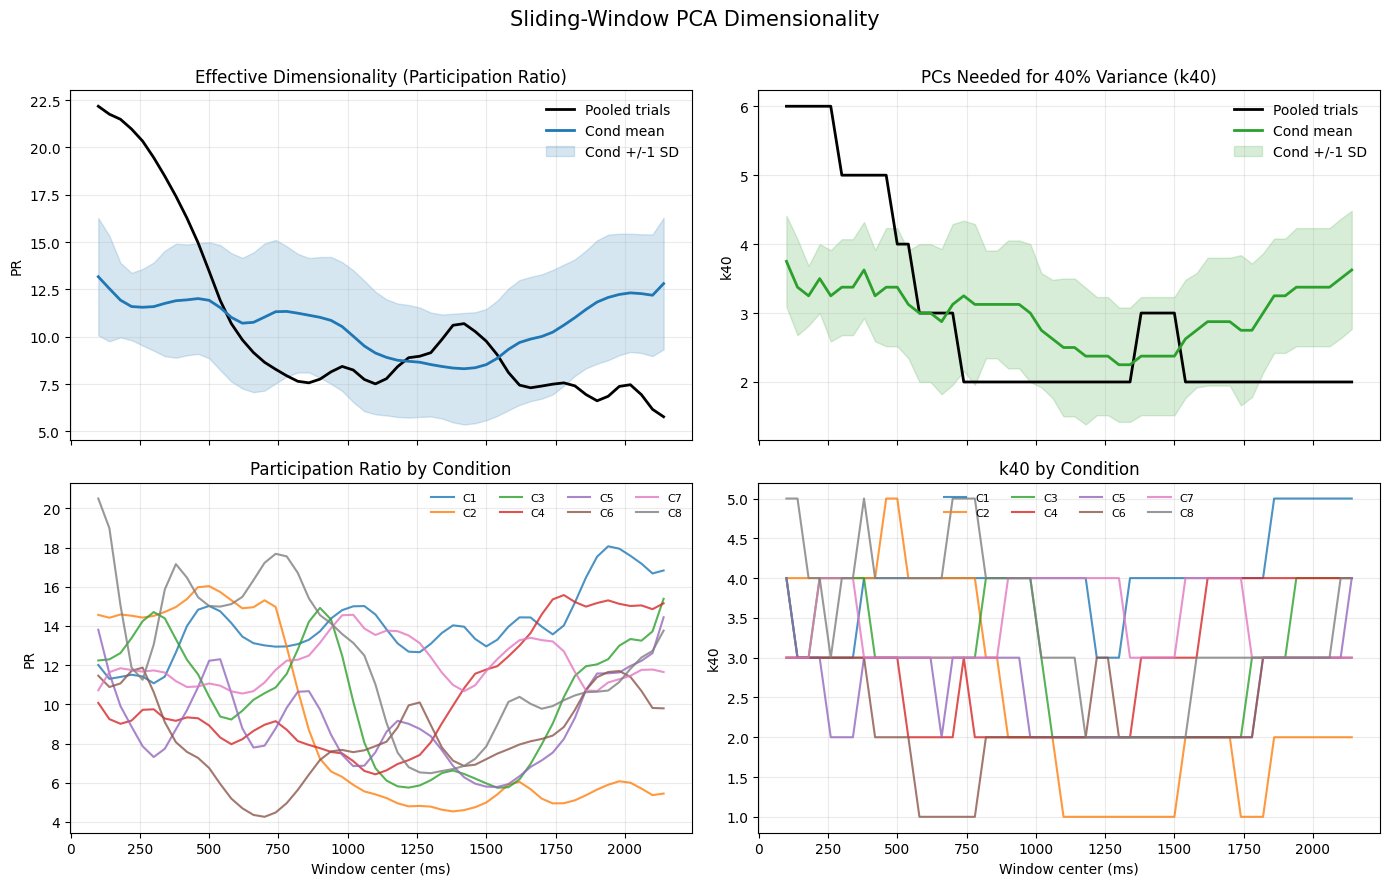

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- Sliding-window PCA dimensionality analysis ----
# Goal: test whether neural dimensionality changes over time.
# Metrics per window:
# - participation ratio (effective dimensionality)
# - number of PCs needed to explain a chosen variance threshold (k_thresh)

if not isinstance(data, dict):
    raise TypeError(f"Expected `data` to be dict, got {type(data).__name__}")


def _find_key(d, candidates):
    for k in d.keys():
        lk = k.lower()
        if any(c in lk for c in candidates):
            return k
    return None


def _as_neuron_time(sp):
    arr = np.asarray(sp)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D spikes array, got shape {arr.shape}")
    return arr if arr.shape[0] <= arr.shape[1] else arr.T


def _pca_dimensionality_metrics(X, variance_threshold=0.90):
    """
    X: observations x neurons
    Returns (participation_ratio, k_thresh, n_obs)
    where k_thresh = # PCs to reach `variance_threshold` explained variance.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[0] < 3 or X.shape[1] < 2:
        return np.nan, np.nan, X.shape[0] if X.ndim == 2 else np.nan

    Xc = X - X.mean(axis=0, keepdims=True)
    _, S, _ = np.linalg.svd(Xc, full_matrices=False)
    eig = (S ** 2) / max(1, (Xc.shape[0] - 1))

    total = eig.sum()
    if total <= 0:
        return np.nan, np.nan, X.shape[0]

    evr = eig / total
    cum = np.cumsum(evr)

    pr = (eig.sum() ** 2) / np.sum(eig ** 2)
    k_thresh = int(np.searchsorted(cum, variance_threshold) + 1)
    return pr, k_thresh, X.shape[0]


spike_key = _find_key(data, ["spike", "spikes"])
cond_key = _find_key(data, ["condition", "cond", "trialtype", "trial_type", "label"])

if spike_key is None:
    raise KeyError(f"Could not find spikes key. Available keys: {list(data.keys())}")
if cond_key is None:
    raise KeyError(f"Could not find condition key. Available keys: {list(data.keys())}")

spikes = data[spike_key]
conds = np.asarray(data[cond_key]).ravel()
cond_ids = np.arange(1, 9)

if len(spikes) != len(conds):
    raise ValueError(
        f"Mismatch: len(data['{spike_key}'])={len(spikes)} vs len(data['{cond_key}'])={len(conds)}"
    )

# Preprocessing parameters
bin_ms = 20.0
smooth_ms = 40.0

# Sliding-window parameters (in bins)
win_bins = 10   # 10*20ms = 200 ms windows
step_bins = 2   # 2*20ms = 40 ms step

# Dimensionality threshold parameter (set this)
variance_threshold = 0.40  # e.g., 0.90, 0.95, 0.99
if not (0 < variance_threshold <= 1):
    raise ValueError("variance_threshold must be in (0, 1].")

# Build trial x neuron x time-bins firing-rate tensor
T_min = min(_as_neuron_time(s).shape[1] for s in spikes)
N_units = _as_neuron_time(spikes[0]).shape[0]
n_bins = int(T_min // bin_ms)

trial_rates = []
for s in spikes:
    st = _as_neuron_time(s)[:, : int(n_bins * bin_ms)]
    binned = st.reshape(N_units, n_bins, int(bin_ms)).sum(axis=2)
    rate_hz = binned * (1000.0 / bin_ms)
    trial_rates.append(rate_hz)
trial_rates = np.stack(trial_rates, axis=0)  # (trials, units, bins)
trial_rates = gaussian_filter1d(trial_rates, sigma=(smooth_ms / bin_ms), axis=2, mode="nearest")

# trial_rates_t: (trials, bins, units)
trial_rates_t = np.transpose(trial_rates, (0, 2, 1))

starts = np.arange(0, n_bins - win_bins + 1, step_bins)
centers = starts + win_bins / 2.0
centers_ms = centers * bin_ms

# Store pooled metrics over time
pooled_pr = []
pooled_kth = []
pooled_nobs = []

# Store condition-specific metrics: dict[cond] -> list over windows
cond_pr = {c: [] for c in cond_ids}
cond_kth = {c: [] for c in cond_ids}

for s in starts:
    e = s + win_bins

    # One vector per trial: window-averaged firing per neuron
    X_pool = trial_rates_t[:, s:e, :].mean(axis=1)  # (trials, units)
    pr, kth, nobs = _pca_dimensionality_metrics(X_pool, variance_threshold=variance_threshold)
    pooled_pr.append(pr)
    pooled_kth.append(kth)
    pooled_nobs.append(nobs)

    # Per-condition
    for c in cond_ids:
        idx = np.where(conds == c)[0]
        if len(idx) < 3:
            cond_pr[c].append(np.nan)
            cond_kth[c].append(np.nan)
            continue

        Xc = trial_rates_t[idx, s:e, :].mean(axis=1)
        pr_c, kth_c, _ = _pca_dimensionality_metrics(Xc, variance_threshold=variance_threshold)
        cond_pr[c].append(pr_c)
        cond_kth[c].append(kth_c)

pooled_pr = np.array(pooled_pr)
pooled_kth = np.array(pooled_kth)

# Aggregate across conditions (mean +- std)
cond_pr_mat = np.vstack([cond_pr[c] for c in cond_ids])
cond_kth_mat = np.vstack([cond_kth[c] for c in cond_ids])

mean_cond_pr = np.nanmean(cond_pr_mat, axis=0)
std_cond_pr = np.nanstd(cond_pr_mat, axis=0)
mean_cond_kth = np.nanmean(cond_kth_mat, axis=0)
std_cond_kth = np.nanstd(cond_kth_mat, axis=0)

k_label = f"k{int(round(variance_threshold * 100))}"

print(
    f"Sliding windows: {len(starts)} | window={win_bins} bins ({win_bins*bin_ms:.0f} ms), "
    f"step={step_bins} bins ({step_bins*bin_ms:.0f} ms), variance threshold={variance_threshold:.2f}"
)
print("Interpretation tip: rising PR/k suggests higher dimensional population activity.")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

# 1) pooled participation ratio
axes[0, 0].plot(centers_ms, pooled_pr, color="black", lw=2, label="Pooled trials")
axes[0, 0].plot(centers_ms, mean_cond_pr, color="tab:blue", lw=2, label="Cond mean")
axes[0, 0].fill_between(
    centers_ms,
    mean_cond_pr - std_cond_pr,
    mean_cond_pr + std_cond_pr,
    color="tab:blue",
    alpha=0.18,
    label="Cond +/-1 SD",
)
axes[0, 0].set_title("Effective Dimensionality (Participation Ratio)")
axes[0, 0].set_ylabel("PR")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend(frameon=False)

# 2) pooled k-threshold
axes[0, 1].plot(centers_ms, pooled_kth, color="black", lw=2, label="Pooled trials")
axes[0, 1].plot(centers_ms, mean_cond_kth, color="tab:green", lw=2, label="Cond mean")
axes[0, 1].fill_between(
    centers_ms,
    mean_cond_kth - std_cond_kth,
    mean_cond_kth + std_cond_kth,
    color="tab:green",
    alpha=0.18,
    label="Cond +/-1 SD",
)
axes[0, 1].set_title(f"PCs Needed for {int(round(variance_threshold*100))}% Variance ({k_label})")
axes[0, 1].set_ylabel(k_label)
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend(frameon=False)

# 3) PR by condition
for c in cond_ids:
    axes[1, 0].plot(centers_ms, cond_pr[c], lw=1.5, alpha=0.8, label=f"C{c}")
axes[1, 0].set_title("Participation Ratio by Condition")
axes[1, 0].set_xlabel("Window center (ms)")
axes[1, 0].set_ylabel("PR")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(frameon=False, ncol=4, fontsize=8)

# 4) k-threshold by condition
for c in cond_ids:
    axes[1, 1].plot(centers_ms, cond_kth[c], lw=1.5, alpha=0.8, label=f"C{c}")
axes[1, 1].set_title(f"{k_label} by Condition")
axes[1, 1].set_xlabel("Window center (ms)")
axes[1, 1].set_ylabel(k_label)
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(frameon=False, ncol=4, fontsize=8)

fig.suptitle("Sliding-Window PCA Dimensionality", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

